In [11]:
# Manipulación y análisis de datos
import pandas as pd
import numpy as np

# Rutas y utilidades
from pathlib import Path
import platform

# Visualización
import matplotlib
import matplotlib.pyplot as plt

# Métricas y modelo base aprendido
import sklearn
from sklearn.metrics import mean_poisson_deviance, mean_absolute_error, mean_squared_error
from sklearn.tree import DecisionTreeRegressor

# Semilla global: hoy no hay nada aleatorio, pero lo dejamos fijado por si se agrega.
SEMILLA = 42
np.random.seed(SEMILLA)

plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

print("pandas      ", pd.__version__)
print("numpy       ", np.__version__)
print("matplotlib  ", matplotlib.__version__)
print("scikit-learn", sklearn.__version__)
print("python      ", platform.python_version())

pandas       3.0.5
numpy        2.5.2
matplotlib   3.11.1
scikit-learn 1.9.0
python       3.13.2


In [19]:
df = pd.read_csv("data/processed/panel_zona_top.csv", index_col=0)
df.head()

,zona_id,n_siniestros,tipo_dia,temp_media,temp_max,temp_min,precipitacion_mm,lluvia_mm,viento_max_kmh,estado_clima,llovio
fecha,,,,,,,,,,,
2021-07-01,MUNICIPIO C,5,entre_semana,11.2,14.9,9.4,0.0,0.0,19.6,nublado,0
2021-07-02,MUNICIPIO C,8,entre_semana,10.4,13.0,8.5,0.0,0.0,22.7,nublado,0
2021-07-03,MUNICIPIO C,2,fin_semana,10.9,14.7,8.0,0.0,0.0,24.4,despejado,0
2021-07-04,MUNICIPIO C,4,fin_semana,9.8,15.0,6.0,0.0,0.0,20.4,nublado,0
2021-07-05,MUNICIPIO C,2,entre_semana,9.7,15.7,5.2,0.0,0.0,14.8,despejado,0


In [20]:
df.index = pd.to_datetime(df.index)
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 1645 entries, 2021-07-01 to 2025-12-31
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   zona_id           1645 non-null   str    
 1   n_siniestros      1645 non-null   int64  
 2   tipo_dia          1645 non-null   str    
 3   temp_media        1645 non-null   float64
 4   temp_max          1645 non-null   float64
 5   temp_min          1645 non-null   float64
 6   precipitacion_mm  1645 non-null   float64
 7   lluvia_mm         1645 non-null   float64
 8   viento_max_kmh    1645 non-null   float64
 9   estado_clima      1645 non-null   str    
 10  llovio            1645 non-null   int64  
dtypes: float64(6), int64(2), str(3)
memory usage: 200.8 KB


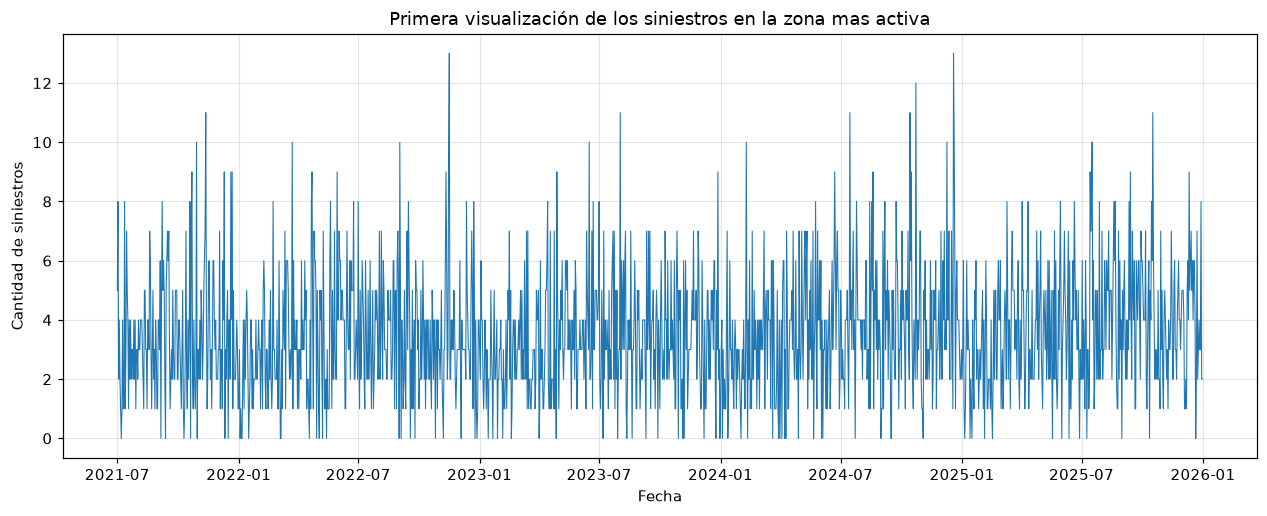

In [21]:
plt.figure(figsize=(14, 5))
plt.plot(df.index, df["n_siniestros"], linewidth=0.7)

plt.title("Primera visualización de los siniestros en la zona mas activa")
plt.xlabel("Fecha")
plt.ylabel("Cantidad de siniestros")
plt.grid(True)
plt.show()

In [22]:
# Definimos el tamaño del conjunto de prueba
# En este caso reservamos el 20% final de la serie
n_test = int(len(df) * 0.2)

# Partición temporal
train = df.iloc[:-n_test].copy()
test = df.iloc[-n_test:].copy()

# Verificamos los períodos obtenidos
print("Conjunto de entrenamiento:")
print(train.index.min(), "→", train.index.max())
print("Cantidad de registros:", len(train))

print("\nConjunto de prueba:")
print(test.index.min(), "→", test.index.max())
print("Cantidad de registros:", len(test))

Conjunto de entrenamiento:
2021-07-01 00:00:00 → 2025-02-05 00:00:00
Cantidad de registros: 1316

Conjunto de prueba:
2025-02-06 00:00:00 → 2025-12-31 00:00:00
Cantidad de registros: 329


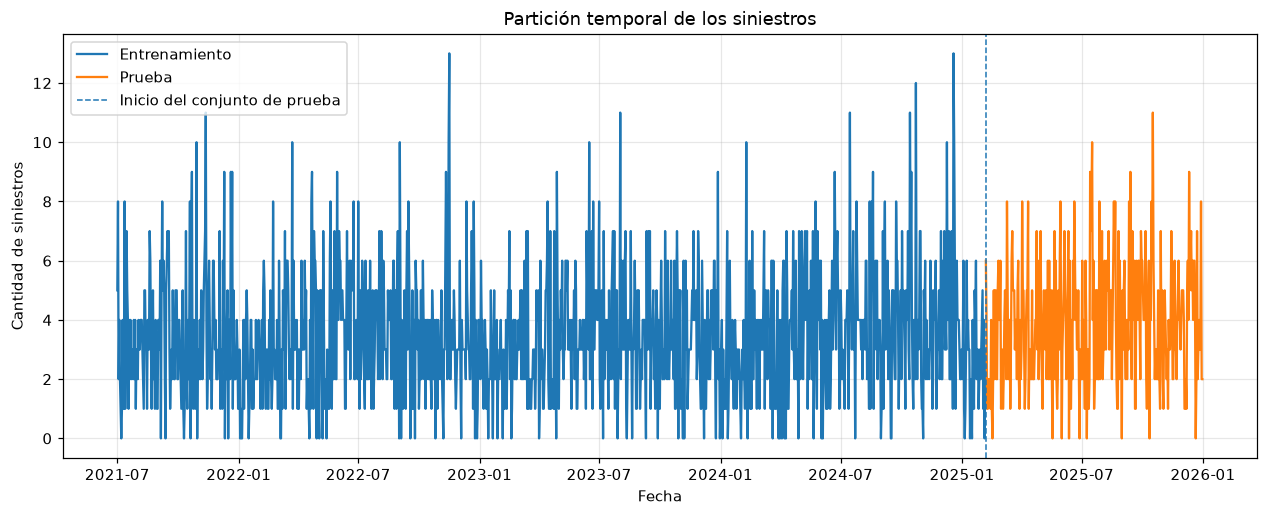

In [23]:
plt.figure(figsize=(14, 5))

plt.plot(train.index, train["n_siniestros"], label="Entrenamiento")
plt.plot(test.index, test["n_siniestros"], label="Prueba")

plt.axvline(test.index.min(), linestyle="--", linewidth=1, label="Inicio del conjunto de prueba")

plt.title("Partición temporal de los siniestros")
plt.xlabel("Fecha")
plt.ylabel("Cantidad de siniestros")
plt.legend()
plt.grid(True)
plt.show()

In [24]:
# Revisamos desde cuándo hasta cuándo llega la serie temporal.
# Como "fecha" es el índice, usamos df.index.min() y df.index.max().
df.index.min(), df.index.max()

(Timestamp('2021-07-01 00:00:00'), Timestamp('2025-12-31 00:00:00'))

In [25]:
# Calculamos la diferencia de tiempo entre cada observación y la anterior.
# Luego contamos cuántas veces aparece cada separación temporal.
df.index.to_series().diff().value_counts().head()

fecha
1 days    1644
Name: count, dtype: int64

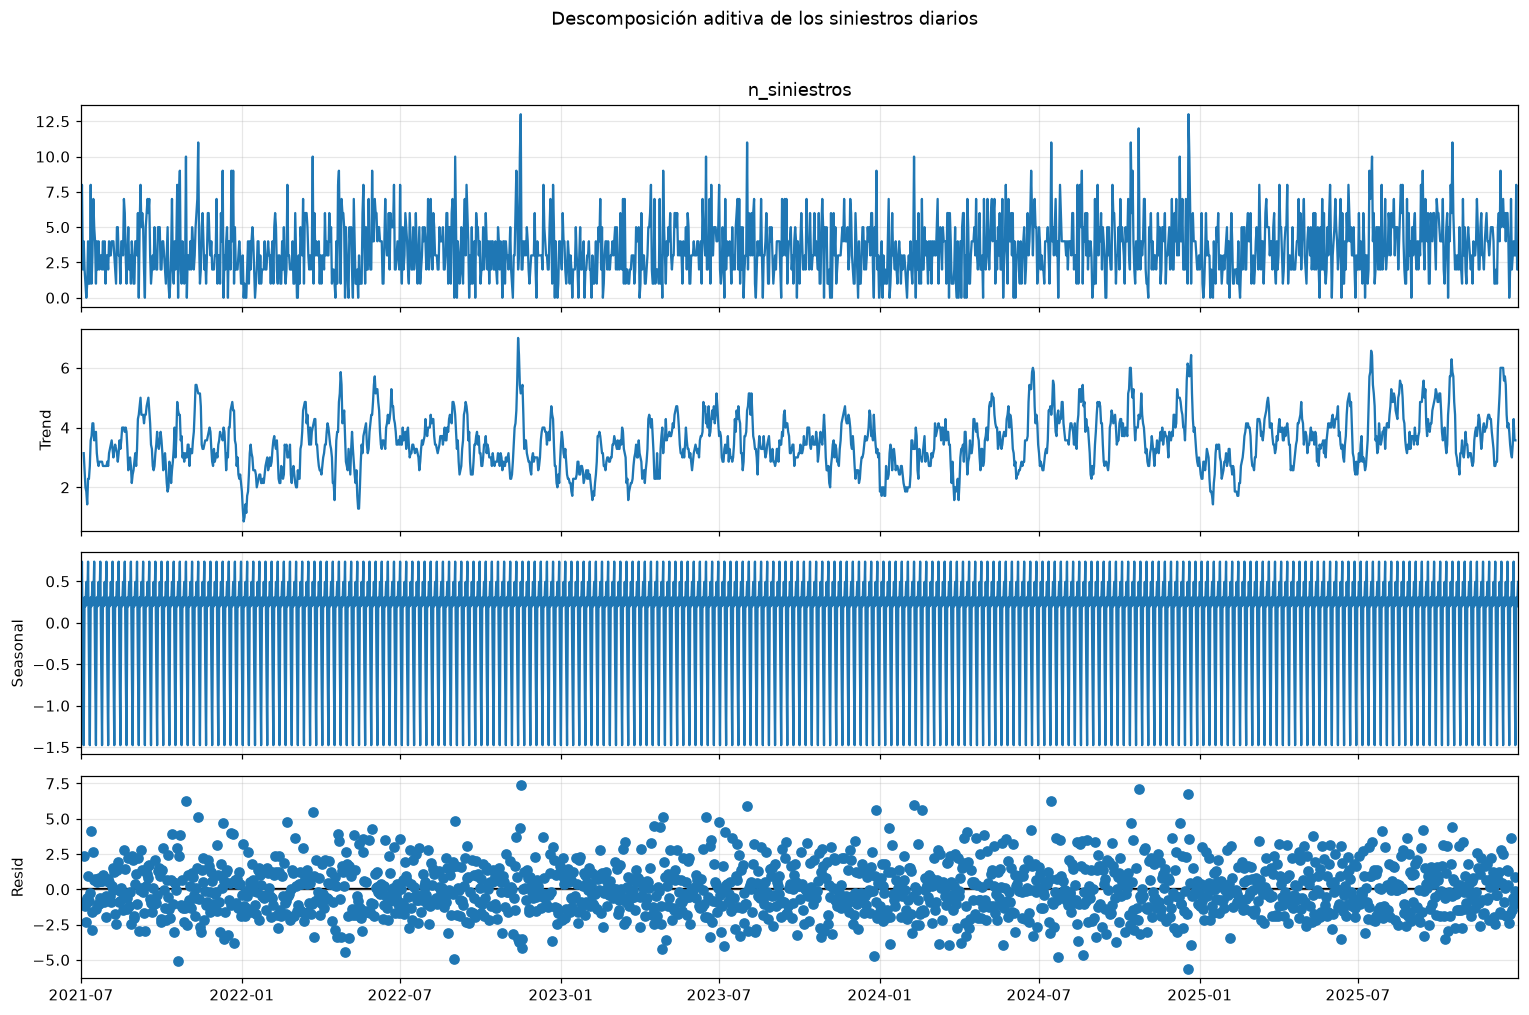

In [27]:
# Importamos la función para descomponer series temporales.
from statsmodels.tsa.seasonal import seasonal_decompose

# Aplicamos una descomposición aditiva sobre la variable objetivo diaria.
# Usamos dropna() porque la función no admite valores faltantes.
# period=7 indica que exploramos un posible patrón semanal.
descomposicion = seasonal_decompose(
    df["n_siniestros"].dropna(),
    model="additive",
    period=7
)

# Graficamos la serie observada, la tendencia, la estacionalidad y el residuo.
fig = descomposicion.plot()

# Aumentamos el tamaño general de la figura.
fig.set_size_inches(14, 9)

# Agregamos un título general.
fig.suptitle(
    "Descomposición aditiva de los siniestros diarios",
    y=1.02
)

plt.tight_layout()
plt.show()

,cnt,cnt_dia_anterior,cnt_semana_anterior
fecha,,,
2021-07-01,5,NaN,NaN
2021-07-02,8,5.0,NaN
2021-07-03,2,8.0,NaN
2021-07-04,4,2.0,NaN
2021-07-05,2,4.0,NaN
2021-07-06,1,2.0,NaN
2021-07-07,0,1.0,NaN
2021-07-08,1,0.0,5.0
2021-07-09,4,1.0,8.0


Autocorrelación con el día anterior: 0.079
Autocorrelación con una semana atrás: 0.077


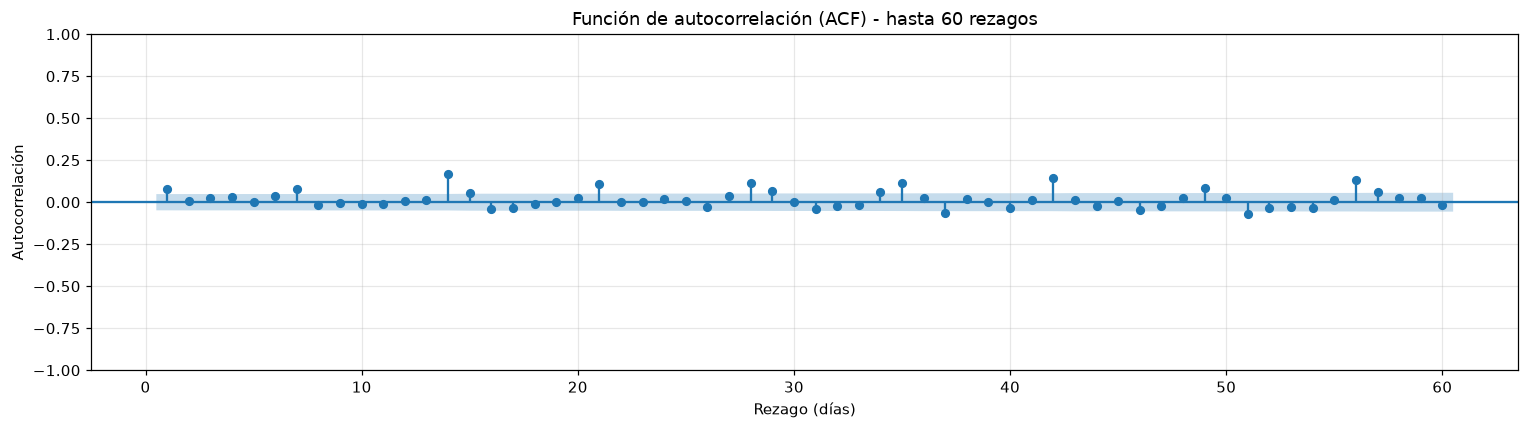

In [28]:
from statsmodels.graphics.tsaplots import plot_acf

# Construimos una tabla auxiliar para comparar la demanda diaria
# con la demanda del día anterior.
comparacion = pd.DataFrame({
    "cnt": df["n_siniestros"],
    "cnt_dia_anterior": df["n_siniestros"].shift(1),
    "cnt_semana_anterior": df["n_siniestros"].shift(7)
})

# Mostramos las primeras filas de la comparación.
display(comparacion.head(10))

# Calculamos la autocorrelación con el día anterior.
autocorr_1_dia = df["n_siniestros"].corr(df["n_siniestros"].shift(1))

# Calculamos la autocorrelación con una semana de rezago.
autocorr_7_dias = df["n_siniestros"].corr(df["n_siniestros"].shift(7))

print("Autocorrelación con el día anterior:", round(autocorr_1_dia, 3))
print("Autocorrelación con una semana atrás:", round(autocorr_7_dias, 3))

# Definimos cuántos rezagos queremos mostrar en el gráfico ACF.
# Este valor se puede cambiar, por ejemplo a 30, 60 o 90.
n_rezagos = 60

# Graficamos la función de autocorrelación.

fig, ax = plt.subplots(figsize=(14, 4))

plot_acf(
    df["n_siniestros"].dropna(),
    lags=n_rezagos,
    zero=False,
    ax=ax
)

plt.title(f"Función de autocorrelación (ACF) - hasta {n_rezagos} rezagos")
plt.xlabel("Rezago (días)")
plt.ylabel("Autocorrelación")

plt.tight_layout()
plt.show()

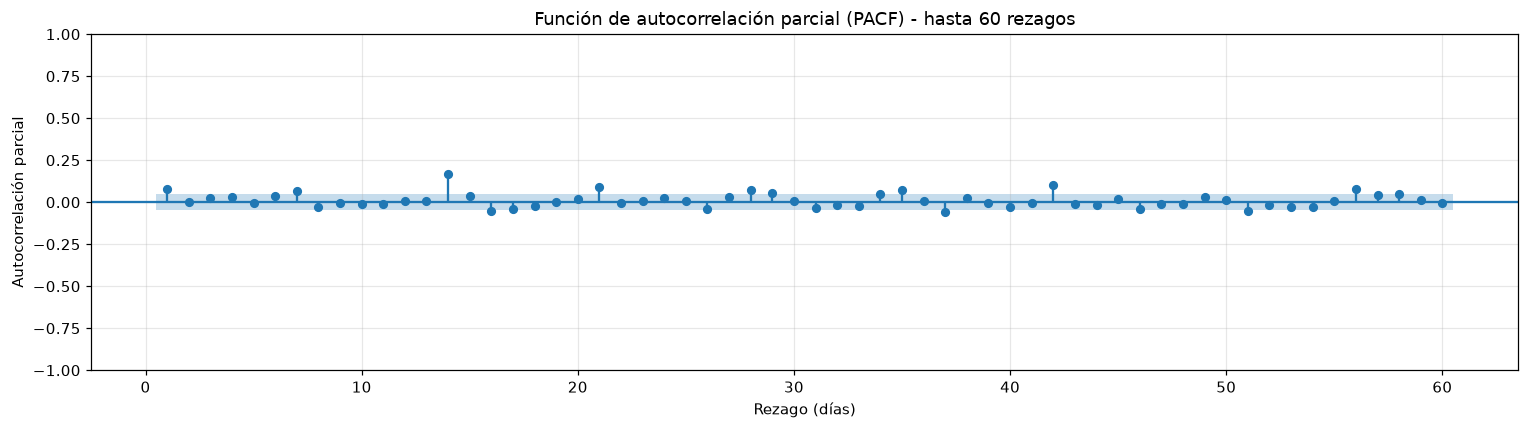

In [29]:
from statsmodels.graphics.tsaplots import plot_pacf

# Definimos cuántos rezagos queremos visualizar.
# Como estamos trabajando con datos diarios, 60 rezagos equivalen aproximadamente a dos meses.
n_rezagos = 60

# Creamos la figura y el eje para evitar que se genere una figura vacía.
fig, ax = plt.subplots(figsize=(14, 4))

# Graficamos la función de autocorrelación parcial.
plot_pacf(
    df["n_siniestros"].dropna(),
    lags=n_rezagos,
    method="ywm",
    zero=False,
    ax=ax
)

ax.set_title(f"Función de autocorrelación parcial (PACF) - hasta {n_rezagos} rezagos")
ax.set_xlabel("Rezago (días)")
ax.set_ylabel("Autocorrelación parcial")

plt.tight_layout()
plt.show()

In [30]:
# Seleccionamos la serie objetivo diaria.
# Usamos solamente "cnt", que representa la cantidad diaria de bicicletas alquiladas.
serie = df["n_siniestros"].copy()

# Definimos el tamaño del conjunto de prueba.
# En este caso usamos el 20% final de la serie para test.
test_size = int(len(serie) * 0.2)

# Separamos respetando el orden temporal.
# Train contiene el primer 80% de la serie.
# Test contiene el último 20% de la serie.
train = serie.iloc[:-test_size]
test = serie.iloc[-test_size:]

# Mostramos la cantidad de observaciones en cada conjunto.
print("Cantidad de observaciones en train:", len(train))
print("Cantidad de observaciones en test:", len(test))

# Mostramos los rangos temporales de cada conjunto.
print("Rango de train:", train.index.min(), "a", train.index.max())
print("Rango de test:", test.index.min(), "a", test.index.max())

Cantidad de observaciones en train: 1316
Cantidad de observaciones en test: 329
Rango de train: 2021-07-01 00:00:00 a 2025-02-05 00:00:00
Rango de test: 2025-02-06 00:00:00 a 2025-12-31 00:00:00


In [31]:
# Instalamos skforecast en el entorno de Colab.
!pip install skforecast

  Using cached rich-15.0.0-py3-none-any.whl.metadata (18 kB)
  Using cached markdown_it_py-4.2.0-py3-none-any.whl.metadata (7.4 kB)
  Using cached mdurl-0.1.2-py3-none-any.whl.metadata (1.6 kB)
   ---------------------------------------- 0.0/529.7 kB ? eta -:--:--
   ---------------------------------------- 0.0/529.7 kB ? eta -:--:--
   ---------------------------------------- 0.0/529.7 kB ? eta -:--:--
   ---------------------------------------- 529.7/529.7 kB 3.2 MB/s  0:00:00
   ---------------------------------------- 0.0/11.0 MB ? eta -:--:--
   ----------- ---------------------------- 3.1/11.0 MB 18.0 MB/s eta 0:00:01
   ------------ --------------------------- 3.4/11.0 MB 11.3 MB/s eta 0:00:01
   ------------- -------------------------- 3.7/11.0 MB 5.7 MB/s eta 0:00:02
   -------------- ------------------------- 3.9/11.0 MB 4.6 MB/s eta 0:00:02
   --------------- ------------------------ 4.2/11.0 MB 4.3 MB/s eta 0:00:02
   --------------- ------------------------ 4.2/11.0 MB 4.3

  You can safely remove it manually.


In [ ]:
# Importamos el forecaster recursivo de skforecast.
from skforecast.recursive import ForecasterRecursive

# Importamos el modelo de machine learning que usaremos como estimador interno.
# Importamos el modelo de machine learning que usaremos como estimador interno.

forecaster = ForecasterRecursive(
    estimator=DecisionTreeRegressor(
        max_depth=5,
        random_state=SEMILLA
    ),
    lags=7
)

forecaster.fit(y=train)

forecaster


ImportError: cannot import name 'desiciontree' from 'sklearn' (c:\Users\victo\Desktop\Proyectos\prediccion-siniestros-viales\.venv\Lib\site-packages\sklearn\__init__.py)